# 1 — Read and understand CTD files with PyLake

## Learning goals

At the end of this notebook, you will be able to:

1. explain what a CTD profile contains;
2. open four supported file formats with `pylake.read`;
3. understand the dimensions, coordinates, and variables in the result;
4. display measurements as a table and as a depth profile;
5. diagnose the most common reading errors.

No private dataset or internet connection is needed. The repository contains small reproducible files that you can safely modify.

## What is a CTD profile?

**CTD** means **Conductivity, Temperature, Depth**. A CTD instrument is lowered through the water and records measurements at successive depths. Depending on the instrument, a file may also contain pressure, oxygen, chlorophyll, turbidity, or pH.

In this tutorial, depth increases downward. A temperature profile therefore answers a simple question: **how does water temperature change from the surface to the bottom?**

## Before running the notebook

Open the notebook from the PyLake repository and select the Python environment in which PyLake is installed. It works whether Jupyter starts in the repository root or in `notebooks/`. Execute the cells from top to bottom. If a cell fails, read the explanation immediately above it before changing the code.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import pylake

repository_root = Path.cwd()
if not (repository_root / "examples").is_dir():
    repository_root = repository_root.parent
if not (repository_root / "examples").is_dir():
    raise FileNotFoundError("Run this notebook from the PyLake repository or its notebooks directory.")
sys.path.insert(0, str(repository_root))

from examples.generate_ctd_examples import main as generate_examples

data_directory = generate_examples()
data_directory

PosixPath('/Users/wahboulet/Projects/PyLake/examples/data')

## The four example formats

PyLake supports several exporters because CTD manufacturers and data platforms do not all store measurements in the same way.

| Example | Origin | Main idea |
|---|---|---|
| `example_datalakes.json` | DataLakes | several temperature profiles on a time × depth grid |
| `example.rsk` | RBR | instrument database containing channels and metadata |
| `example_kor.csv` | KOR | text table with date, time, depth, and temperature |
| `example.tob` | Sea & Sun | text export containing several water-quality variables |

All four files contain deterministic synthetic measurements. They exist to teach and test the readers; they are not observations from a real lake.

In [2]:
example_files = sorted(data_directory.iterdir())
pd.DataFrame({
    "file": [path.name for path in example_files],
    "size_bytes": [path.stat().st_size for path in example_files],
})

,file,size_bytes
0,example.rsk,12288
1,example.tob,1334
2,example_datalakes.json,1398
3,example_kor.csv,1602


## Look at the file before using PyLake

A TOB file is ordinary text. Header lines begin with `;`, followed by rows of measurements. Looking at a few lines makes the reader less mysterious: PyLake is translating this instrument-specific layout into named scientific variables.

> **Good habit:** inspect a small part of an unfamiliar file, but never edit the original field file directly.

In [3]:
tob_preview = (data_directory / "example.tob").read_text(encoding="latin-1").splitlines()
print("\n".join(tob_preview[:7]))

; Sea & Sun CTD example
; Datasets
; columns
; units
1 0.000 20.998 0.40 0.10 0.20 7.2 98.0 9.0 01.01.2026 00:00:00
2 1.000 20.745 0.40 0.10 0.20 7.2 98.0 9.0 01.01.2026 00:00:01
3 2.000 20.488 0.40 0.10 0.20 7.2 98.0 9.0 01.01.2026 00:00:02


## Start with one file

`pylake.read(path)` is the normal entry point. It examines the file and chooses the appropriate reader automatically.

In [4]:
tob_path = data_directory / "example.tob"
tob = pylake.read(tob_path)
tob

<xarray.Dataset> Size: 1kB
Dimensions:            (time: 20)
Coordinates:
  * time               (time) datetime64[us] 160B 2026-01-01 ... 2026-01-01T0...
Data variables:
    pressure           (time) float64 160B 0.0 1.0 2.0 3.0 ... 17.0 18.0 19.0
    temperature        (time) float64 160B 21.0 20.75 20.49 ... 11.75 11.5 11.25
    conductivity       (time) float64 160B 0.4 0.4 0.4 0.4 ... 0.4 0.4 0.4 0.4
    chlorophyll        (time) float64 160B 0.1 0.1 0.1 0.1 ... 0.1 0.1 0.1 0.1
    turbidity          (time) float64 160B 0.2 0.2 0.2 0.2 ... 0.2 0.2 0.2 0.2
    pH                 (time) float64 160B 7.2 7.2 7.2 7.2 ... 7.2 7.2 7.2 7.2
    oxygen_saturation  (time) float64 160B 98.0 98.0 98.0 ... 98.0 98.0 98.0
    oxygen_mg_l        (time) float64 160B 9.0 9.0 9.0 9.0 ... 9.0 9.0 9.0 9.0
Attributes:
    source:   Sea & Sun

## How to read an `xarray.Dataset`

The object displayed above is an `xarray.Dataset`:

- **Dimensions** give the size of each axis. Here, `time: 20` means 20 measurements.
- **Coordinates** identify positions on those axes, such as timestamps.
- **Data variables** contain the measurements, such as temperature and pressure.
- **Attributes** contain metadata describing the source.

Unlike an anonymous numerical matrix, a Dataset keeps names, coordinates, and metadata next to the values.

In [5]:
summary = {
    "dimensions": dict(tob.sizes),
    "coordinates": list(tob.coords),
    "variables": list(tob.data_vars),
    "detected_source": tob.attrs.get("source"),
}
summary

{'dimensions': {'time': 20},
 'coordinates': ['time'],
 'variables': ['pressure',
  'temperature',
  'conductivity',
  'chlorophyll',
  'turbidity',
  'pH',
  'oxygen_saturation',
  'oxygen_mg_l'],
 'detected_source': 'Sea & Sun'}

## Turn selected variables into a readable table

The first five rows let us check whether the values and units look plausible before doing any scientific calculation.

In [6]:
tob_table = tob[["pressure", "temperature", "oxygen_mg_l"]].to_dataframe()
tob_table.head()

,pressure,temperature,oxygen_mg_l
time,,,
2026-01-01 00:00:00,0.0,20.998,9.0
2026-01-01 00:00:01,1.0,20.745,9.0
2026-01-01 00:00:02,2.0,20.488,9.0
2026-01-01 00:00:03,3.0,20.217,9.0
2026-01-01 00:00:04,4.0,19.910,9.0


## Plot the temperature profile

Scientific profiles conventionally place temperature on the horizontal axis and depth or pressure on the vertical axis. The vertical axis is inverted so the surface appears at the top.

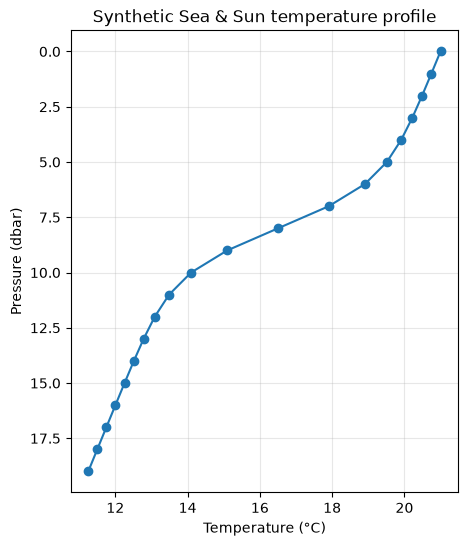

In [7]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(tob["temperature"], tob["pressure"], marker="o")
ax.invert_yaxis()
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (dbar)")
ax.set_title("Synthetic Sea & Sun temperature profile")
ax.grid(alpha=0.3)
plt.show()

### Interpretation

The example is warm near the surface and colder at depth. The strongest temperature change occurs around the middle of the profile. Later notebooks will estimate the thermocline associated with this transition.

## Read every format with the same public function

The purpose of `pylake.read` is to hide format-specific parsing from the user. The following loop opens every example and reports the detected source and available variables.

In [8]:
rows = []
datasets = {}

for path in example_files:
    dataset = pylake.read(path)
    datasets[path.name] = dataset
    rows.append({
        "file": path.name,
        "source": dataset.attrs.get("source"),
        "dimensions": dict(dataset.sizes),
        "variables": ", ".join(dataset.data_vars),
    })

pd.DataFrame(rows)

,file,source,dimensions,variables
0,example.rsk,RBR,{'time': 20},"temp14, pres24"
1,example.tob,Sea & Sun,{'time': 20},"pressure, temperature, conductivity, chlorophy..."
2,example_datalakes.json,DataLakes,"{'time': 3, 'depth': 20}","temperature, mixed_layer_depth, thermocline_depth"
3,example_kor.csv,KOR,{'time': 20},"Depth, Temperature"


## When should specialized readers be used?

Most users should call `pylake.read`. Specialized readers are useful when the format is already known or when automatic detection is being diagnosed.

| Function | Format |
|---|---|
| `read_datalakes` | DataLakes JSON, NetCDF, or ZIP |
| `read_rsk` | RBR `.rsk` |
| `read_kor` | KOR CSV export |
| `read_tob` | Sea & Sun TOB export |
| `datalakes_to_xarray` | DataLakes dictionary already loaded in memory |

In [9]:
specialized = {
    "DataLakes": pylake.read_datalakes(data_directory / "example_datalakes.json"),
    "RBR": pylake.read_rsk(data_directory / "example.rsk"),
    "KOR": pylake.read_kor(data_directory / "example_kor.csv"),
    "Sea & Sun": pylake.read_tob(data_directory / "example.tob"),
}

{name: dict(dataset.sizes) for name, dataset in specialized.items()}

{'DataLakes': {'time': 3, 'depth': 20},
 'RBR': {'time': 20},
 'KOR': {'time': 20},
 'Sea & Sun': {'time': 20}}

## DataLakes dictionaries

A DataLakes export uses `x` for time, `y` for depth, and `z` for the temperature matrix. `datalakes_to_xarray` is useful when that dictionary has already been obtained from an API or decoded from JSON.

In [10]:
import json

datalakes_path = data_directory / "example_datalakes.json"
payload = json.loads(datalakes_path.read_text())
datalakes_from_memory = pylake.datalakes_to_xarray(payload)
datalakes_from_memory["temperature"].isel(time=0).to_dataframe().head()

,time,temperature
depth,,
0.0,1970-01-01,20.998
1.0,1970-01-01,20.745
2.0,1970-01-01,20.488
3.0,1970-01-01,20.217
4.0,1970-01-01,19.910


## Use your own file

Replace the path below with a real CTD file. Keeping the existence check makes the cell safe before a path has been selected.

In [11]:
my_file = Path("path/to/my/profile.rsk")

if my_file.exists():
    my_dataset = pylake.read(my_file)
    display(my_dataset)
else:
    print("Choose a real file path when you are ready.")

Choose a real file path when you are ready.


## Understand common failures

- `FileNotFoundError`: Python cannot find the path.
- Unsupported-source `ValueError`: the format was not recognized.
- Shape error in DataLakes: the temperature matrix does not match time and depth.
- Parsing error: the real exporter uses a layout not represented by the reader.

When a real file fails, preserve the smallest shareable example that still reproduces the failure.

In [12]:
try:
    pylake.read("missing-profile.rsk")
except FileNotFoundError as error:
    print(f"Expected example: {type(error).__name__}: {error}")

Expected example: FileNotFoundError: missing-profile.rsk


## Check your understanding

1. Change `example.tob` to `example.rsk` and identify the temperature and pressure variable names.
2. Display the last five rows rather than the first five.
3. Change the plot title and marker.
4. Explain, in one sentence, why `pylake.read` is preferable for a new user.

<details>
<summary><strong>Suggested answers</strong></summary>

1. The RSK temperature and pressure variables are `temp14` and `pres24`.
2. Replace `.head()` with `.tail()`.
3. Edit `ax.set_title(...)` and the `marker=` argument.
4. `pylake.read` detects the source automatically, so the user does not need to select a format-specific parser.

</details>

## Take-away

`pylake.read` provides one public interface for different CTD formats. Always inspect the Dataset, a few table rows, and a profile plot before starting scientific analysis.